# Step 2 — Synthetic Data for the Homepage Dek A/B Test

This notebook **generates** the dataset for the Meridian homepage-dek experiment and **verifies it
matches the spec.** It does not analyse the experiment — that is `03-results.ipynb`.

### The design it has to honour (from Step 1)

| | |
|---|---|
| **Treatment** | A one-to-two-sentence factual summary (*dek*) rendered beneath headlines in homepage slots 1–5 |
| **Primary KPI** | Session-denominated CTR — share of homepage sessions with ≥1 article click |
| **Baseline** | 34.1% |
| **Unit of randomisation** | User (sticky) |
| **Unit of analysis** | User — cannot be finer than randomisation |
| **Window** | 2026-09-22 → 2026-10-26 (35 days = 5 whole weeks) |
| **Ship threshold** | +5% relative |
| **Power target** | +2% relative |

### Two design choices worth understanding before reading the code

**Rows are sessions, not users.** Pre-aggregating to one row per user would hide the problem the
plan cares about. With session rows and a repeating `user_id`, the clustering is *in the data*: a
naive session-level test reports a standard error about 11% too small, and the analysis notebook can
demonstrate that rather than assert it.

**`deks_available` and `deks_rendered` are separate columns.** `deks_available` records whether a
reporter wrote a dek — it is logged in **both** arms and is independent of assignment, so it is
safe to filter on. `deks_rendered` is *caused by* treatment (always 0 in arm A), so filtering on it
would strip sessions from one arm only and destroy the randomisation. The two columns exist so the
distinction can be demonstrated instead of described.

## 1. Configuration

Every knob lives here. Change one, re-run the notebook, get a different world.

In [1]:
import csv, math, random
from datetime import date, timedelta

SEED = 20260922
random.seed(SEED)

# --- scale and window ------------------------------------------------------
N_USERS    = 100_000
START      = date(2026, 9, 22)          # launch
END        = date(2026, 10, 26)         # day 35 -> exactly 5 whole weeks
N_DAYS     = (END - START).days + 1

# --- allocation ------------------------------------------------------------
P_ASSIGN_B = 0.48                       # intended A 52 / B 48 (cautious ramp, deliberately uneven)

# --- target rates ----------------------------------------------------------
TARGET_A   = 0.341                      # documented baseline session CTR
TARGET_B   = 0.382                      # +12.0% relative (bottom of the 10-30% band in the brief)

# --- heterogeneity and structure ------------------------------------------
SIGMA_USER     = 1.10                   # user random effect, logit scale -> ICC ~0.27
NEWS_SPIKE_DAY = 18                     # Oct 10: big story

# covariate effects on logit(click)
B_MOBILE, B_DESKTOP, B_TABLET = -0.16, 0.30, 0.05
B_RETURNING, B_NEW            =  0.22, -0.30
B_LOGGED_IN, B_SUBSCRIBER     =  0.28,  0.35

NOVELTY_PEAK, NOVELTY_TAU = 0.25, 9.0   # treatment x (1 + 0.25*exp(-day/9))
DEK_COVERAGE_MEAN         = 0.88        # share of in-scope stories with a dek written
DEK_COVERAGE_SPIKE_DAY    = 0.71        # breaking news outruns dek writing
IMPRESSION_PENALTY_B      = 0.955       # vertical space: ~4.5% fewer headlines seen in arm B

print(f"{N_DAYS} days ({N_DAYS // 7} whole weeks): {START} -> {END}")
print(f"{N_USERS:,} users, intended allocation A {(1-P_ASSIGN_B):.0%} / B {P_ASSIGN_B:.0%}")
print(f"targets: A {TARGET_A:.1%}  B {TARGET_B:.1%}  (rel {TARGET_B/TARGET_A-1:+.1%})")

35 days (5 whole weeks): 2026-09-22 -> 2026-10-26
100,000 users, intended allocation A 52% / B 48%
targets: A 34.1%  B 38.2%  (rel +12.0%)


## 2. Samplers

Stdlib only — no numpy needed for generation. `random.gammavariate` and `random.gauss` do the heavy lifting.

In [2]:
def poisson(lam):
    """Knuth's method. Fine for the small lambdas used here."""
    if lam <= 0:
        return 0
    L, k, p = math.exp(-lam), 0, 1.0
    while True:
        p *= random.random()
        if p <= L:
            return k
        k += 1

def binomial(n, p):
    return sum(1 for _ in range(n) if random.random() < p)

def sigmoid(x):
    if x >= 0:
        return 1.0 / (1.0 + math.exp(-x))
    e = math.exp(x)
    return e / (1.0 + e)

def clamp(x, lo, hi):
    return lo if x < lo else hi if x > hi else x

## 3. Day-level structure

Three things vary by calendar day, and all three matter to the analysis:

- **Traffic** — weekends run at 78–82% of a weekday, plus lognormal day-to-day news noise
- **CTR shift** — weekend reading is slightly stickier per session
- **Dek coverage** — normally ~88%, but it *collapses on the big news day*

That last correlation is deliberate. Coverage and news intensity move together, which is precisely
why the availability-conditioned analysis is a **subgroup** rather than a clean causal estimate:
filtering to full-coverage sessions quietly filters out breaking-news sessions, and those behave
differently for reasons that have nothing to do with deks.

In [3]:
def build_days():
    days = []
    for i in range(N_DAYS):
        d = START + timedelta(days=i)
        dow = d.weekday()                              # 0 = Monday
        traffic = 1.0
        if   dow == 5: traffic = 0.78                  # Sat
        elif dow == 6: traffic = 0.82                  # Sun
        traffic *= math.exp(random.gauss(0, 0.12))     # day-to-day news noise
        ctr_shift = 0.05 if dow >= 5 else 0.0
        coverage  = DEK_COVERAGE_MEAN + random.gauss(0, 0.035)
        if i == NEWS_SPIKE_DAY:
            traffic   *= 1.90
            ctr_shift += 0.18
            coverage   = DEK_COVERAGE_SPIKE_DAY
        days.append({"day_index": i, "date": d.isoformat(),
                     "dow": ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][dow],
                     "traffic": traffic, "ctr_shift": ctr_shift,
                     "coverage": clamp(coverage, 0.55, 0.99)})
    total = sum(x["traffic"] for x in days)
    cum, acc = [], 0.0
    for x in days:
        acc += x["traffic"] / total
        cum.append(acc)
    return days, cum

DAYS, DAY_CUM = build_days()

def pick_day():
    """Binary search on the cumulative traffic weights."""
    r = random.random()
    lo, hi = 0, N_DAYS - 1
    while lo < hi:
        mid = (lo + hi) // 2
        if r <= DAY_CUM[mid]: hi = mid
        else:                 lo = mid + 1
    return lo

print(f"built {len(DAYS)} days")

built 35 days


Have a look at the day table — sort it by any column to see the weekly rhythm and the shock day.

In [4]:
import pandas as pd
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)

days_df = pd.DataFrame(DAYS)
days_df["is_shock"] = days_df["day_index"] == NEWS_SPIKE_DAY
display(days_df.sort_values("traffic", ascending=False).head(8))
print("mean coverage:", round(days_df.coverage.mean(), 4))
print("weekend vs weekday traffic:",
      round(days_df[days_df.dow.isin(["Sat","Sun"])].traffic.mean() /
            days_df[~days_df.dow.isin(["Sat","Sun"])].traffic.mean(), 3))

,day_index,date,dow,traffic,ctr_shift,coverage,is_shock
18,18,2026-10-10,Sat,1.315213,0.23,0.710000,True
0,0,2026-09-22,Tue,1.159226,0.00,0.850367,False
9,9,2026-10-01,Thu,1.148966,0.00,0.912665,False
6,6,2026-09-28,Mon,1.116240,0.00,0.837310,False
8,8,2026-09-30,Wed,1.099107,0.00,0.847641,False
14,14,2026-10-06,Tue,1.079061,0.00,0.900566,False
17,17,2026-10-09,Fri,1.071949,0.00,0.882254,False
22,22,2026-10-14,Wed,1.068073,0.00,0.932661,False


mean coverage: 0.8758
weekend vs weekday traffic: 0.899


## 4. Users

Each user gets a **latent click propensity** drawn from `Normal(0, 1.10)` on the logit scale. This is
the single most important line in the generator: it is what makes a user's sessions correlated with
each other, which is what makes the unit-of-analysis decision from Step 1 actually matter.

At `SIGMA_USER = 1.10` the intra-class correlation is roughly

$$\text{ICC} = \frac{\sigma_u^2}{\sigma_u^2 + \pi^2/3} = \frac{1.21}{1.21 + 3.29} \approx 0.27$$

which at ~1.5 sessions per user implies a design effect near 1.23. Step 1 assumed 1.24.

Session counts are **gamma-Poisson** (negative-binomial), not Poisson — real users are overdispersed:
most visit once, a few visit constantly.

In [5]:
def build_users(n):
    users = []
    for i in range(n):
        logged_in  = random.random() < 0.31
        subscriber = logged_in and random.random() < 0.194     # ~6% of users overall
        r = random.random()
        device = "mobile" if r < 0.68 else ("desktop" if r < 0.97 else "tablet")
        p_new  = 0.08 if logged_in else 0.47
        visitor = "new" if random.random() < p_new else "returning"
        lam = random.gammavariate(0.60, 0.85)                  # overdispersion
        users.append({"id": i,
                      "variant": "B" if random.random() < P_ASSIGN_B else "A",
                      "u": random.gauss(0, SIGMA_USER),
                      "logged_in": logged_in, "subscriber": subscriber,
                      "device": device, "visitor": visitor,
                      "n_sessions": 1 + poisson(lam)})
    return users

## 5. Session generation

The click model is a logistic regression whose coefficients we wrote ourselves:

```
logit(click) = intercept
             + user_effect                        # latent propensity
             + device + visitor_type + login + subscriber
             + day_ctr_shift
             + treat_coef x exposure x novelty
```

`exposure` is `deks_rendered / inscope_impressions` — **zero for every arm-A session**, and for arm B
it is the *fraction* of in-scope headlines that actually carried a dek. That fraction is what creates
genuine ITT dilution: a coverage rate of 88% means arm-B sessions receive, on average, 88% of the
treatment, so the measured ITT effect is ~88% of the full effect.

In [6]:
def gen_sessions(users, intercept, treat_coef, emit=None):
    """Return (rate_A, rate_B). If `emit` is given, call it with each row tuple."""
    n_click_a = n_a = n_click_b = n_b = 0
    sid = 0
    for u in users:
        base = (u["u"]
                + (B_MOBILE  if u["device"] == "mobile"  else
                   B_DESKTOP if u["device"] == "desktop" else B_TABLET)
                + (B_RETURNING if u["visitor"] == "returning" else B_NEW)
                + (B_LOGGED_IN  if u["logged_in"]  else 0.0)
                + (B_SUBSCRIBER if u["subscriber"] else 0.0))
        is_b = u["variant"] == "B"

        for _ in range(u["n_sessions"]):
            sid += 1
            di  = pick_day()
            day = DAYS[di]

            # device can vary session to session
            if random.random() < 0.88:
                device = u["device"]
            else:
                device = random.choice([d for d in ("mobile","desktop","tablet")
                                        if d != u["device"]])

            # headlines seen; arm B sees fewer because deks take vertical space
            mu = 10.2 * (IMPRESSION_PENALTY_B if is_b else 1.0)
            hp = int(clamp(round(math.exp(random.gauss(math.log(mu), 0.45))), 1, 48))

            inscope = min(5, hp)
            skip_p  = 0.18 if device == "mobile" else 0.12
            if inscope > 1 and random.random() < skip_p:
                inscope -= 1

            deks_avail = binomial(inscope, day["coverage"])
            deks_rend  = deks_avail if is_b else 0          # <- never non-zero in arm A
            full_cov   = 1 if deks_avail == inscope else 0

            exposure = (deks_rend / inscope) if inscope else 0.0
            novelty  = 1.0 + NOVELTY_PEAK * math.exp(-di / NOVELTY_TAU)

            logit   = intercept + base + day["ctr_shift"] + treat_coef * exposure * novelty
            clicked = 1 if random.random() < sigmoid(logit) else 0

            if is_b: n_b += 1; n_click_b += clicked
            else:    n_a += 1; n_click_a += clicked

            if emit is not None:
                if clicked:
                    articles = 1 + poisson(0.42)
                    lift     = 1 if exposure > 0 else 0     # better-qualified clicks in B
                    scroll   = int(round(clamp(random.gauss(52 + 2.2*lift, 18), 5, 100)))
                    tpage    = int(round(math.exp(random.gauss(math.log(78) + 0.06*lift, 0.62))))
                    bounced  = 1 if random.random() < (0.38 - 0.025*lift) else 0
                    tail = (articles, scroll, tpage, bounced)
                else:
                    tail = (0, "", "", "")                  # blank, not zero
                emit((f"S{sid:07d}", f"U{u['id']:06d}", u["variant"],
                      day["date"], day["dow"], device,
                      int(u["logged_in"]), int(u["subscriber"]), u["visitor"],
                      hp, inscope, deks_avail, deks_rend, full_cov, clicked, *tail))

    return (n_click_a / n_a if n_a else 0), (n_click_b / n_b if n_b else 0)

## 6. Calibration

We want arm A to land on 34.1% and arm B on 38.2%. Rather than hand-tuning the intercept and the
treatment coefficient, solve for them: generate, measure, step the parameter in logit space, repeat.

Calibration runs against **the same user set that gets written out**, otherwise the realised rates
drift by a few tenths of a point between the calibration sample and the final run.

In [7]:
def calibrate(cal_users, intercept=-0.95, treat=0.55, rounds=9, verbose=True):
    logit_t = lambda p: math.log(p / (1 - p))
    for k in range(rounds):
        random.seed(SEED + 2)
        ra, _ = gen_sessions(cal_users, intercept, treat)
        intercept += (logit_t(TARGET_A) - logit_t(ra)) * 0.95
        random.seed(SEED + 2)
        _, rb = gen_sessions(cal_users, intercept, treat)
        treat += (logit_t(TARGET_B) - logit_t(rb)) * 0.95
        if verbose and (k % 3 == 2 or k == rounds - 1):
            print(f"  round {k+1:>2}: A={ra:.4f} B={rb:.4f}  "
                  f"intercept={intercept:+.4f} treat={treat:+.4f}")
    return intercept, treat

random.seed(SEED + 10)
users = build_users(N_USERS)
print(f"{len(users):,} users built; {sum(u['n_sessions'] for u in users):,} sessions to generate\n")

INTERCEPT, TREAT_COEF = calibrate(users)
print(f"\nsolved: intercept={INTERCEPT:.4f}  treat_coef={TREAT_COEF:.4f}")

100,000 users built; 150,568 sessions to generate



  round  3: A=0.3414 B=0.3873  intercept=-0.9830 treat=+0.2395


  round  6: A=0.3410 B=0.3821  intercept=-0.9836 treat=+0.2284


  round  9: A=0.3410 B=0.3820  intercept=-0.9835 treat=+0.2282

solved: intercept=-0.9835  treat_coef=0.2282


## 7. Write the CSV — with a guard

Two safety rails, because this cell overwrites the dataset that `03-results.ipynb` reports on:

- **`REGENERATE = False`** skips generation entirely and uses the file already on disk. Set it to
  `False` once you are analysing rather than generating, so a top-to-bottom re-run cannot clobber
  your data.
- **A checksum** against the exact file the results doc describes. If you change a knob in cell 1 —
  which is a perfectly reasonable thing to do — the checksum will not match, and the cell says so
  loudly. That is a notice, not an error: it means the numbers in `03-results.ipynb` describe a
  different dataset than the one you now have.

In [8]:
import hashlib, os

# ---------------------------------------------------------------- the guard
REGENERATE      = True     # False -> use the CSV already on disk, do not rewrite it
EXPECTED_SHA256 = "b6d68646e776aca738fb3857147e387350f9aad3907844e030b53bd1b0a4fffe"
# --------------------------------------------------------------------------

HEADER = ["session_id","user_id","variant","session_date","day_of_week","device",
          "is_logged_in","is_subscriber","visitor_type","homepage_impressions",
          "inscope_impressions","deks_available","deks_rendered","full_dek_coverage",
          "clicked","articles_clicked","scroll_depth_pct","time_on_page_sec","bounced"]

OUT = "ab_test_sessions.csv"

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

if REGENERATE or not os.path.exists(OUT):
    if not REGENERATE:
        print(f"{OUT} not found -> generating anyway\n")
    with open(OUT, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(HEADER)
        random.seed(SEED + 11)
        rate_a, rate_b = gen_sessions(users, INTERCEPT, TREAT_COEF, emit=w.writerow)
    print(f"wrote {OUT}")
else:
    import pandas as _pd
    _g = _pd.read_csv(OUT, usecols=["variant","clicked"]).groupby("variant").clicked.mean()
    rate_a, rate_b = _g["A"], _g["B"]
    print(f"REGENERATE = False -> kept the existing {OUT}, nothing overwritten")

print(f"arm A {rate_a:.4%}   arm B {rate_b:.4%}   relative lift {(rate_b/rate_a - 1):+.2%}")

digest = sha256(OUT)
if digest == EXPECTED_SHA256:
    print(f"\nchecksum OK  {digest[:16]}...")
    print("This is the dataset that 03-results.ipynb reports on.")
else:
    print("\n" + "!" * 78)
    print("CHECKSUM MISMATCH — this is not the dataset 03-results.ipynb describes.")
    print(f"  on disk  {digest}")
    print(f"  expected {EXPECTED_SHA256}")
    print("A config value or the seed changed. That is fine and often the point, but every")
    print("number in 03-results.ipynb (+11.90%, z = 14.74, coverage 87.4%, the CXL runs) belongs")
    print("to the old file. Re-run the analysis before quoting any of them.")
    print("!" * 78)

wrote ab_test_sessions.csv
arm A 34.0141%   arm B 38.0633%   relative lift +11.90%

checksum OK  b6d68646e776aca7...
This is the dataset that 03-results.ipynb reports on.


---
# Checking what the generator produced

Everything below reads the CSV back and verifies it is the dataset that was specified: the right
columns, the right invariants, the right shape.

**This is deliberately not the analysis.** Interpreting the experiment — conversion rates, uplift,
significance, guardrails, the recommendation — lives in `03-results.ipynb`. Keeping the two apart
means each question has exactly one home.

In [9]:
df = pd.read_csv(OUT, parse_dates=["session_date"])
print(f"{len(df):,} rows x {df.shape[1]} columns   |   {df.user_id.nunique():,} users   "
      f"|   {df.session_date.dt.date.nunique()} days")
df.head(10)

150,568 rows x 19 columns   |   100,000 users   |   35 days


,session_id,user_id,variant,session_date,day_of_week,device,is_logged_in,is_subscriber,visitor_type,homepage_impressions,inscope_impressions,deks_available,deks_rendered,full_dek_coverage,clicked,articles_clicked,scroll_depth_pct,time_on_page_sec,bounced
0,S0000001,U000000,A,2026-09-24,Thu,mobile,1,0,returning,8,5,5,0,1,0,0,NaN,NaN,NaN
1,S0000002,U000000,A,2026-10-23,Fri,mobile,1,0,returning,16,4,4,0,1,1,1,67.0,118.0,0.0
2,S0000003,U000001,A,2026-09-27,Sun,mobile,0,0,new,15,5,5,0,1,0,0,NaN,NaN,NaN
3,S0000004,U000002,A,2026-09-26,Sat,mobile,0,0,returning,10,5,3,0,0,0,0,NaN,NaN,NaN
4,S0000005,U000003,A,2026-09-29,Tue,desktop,0,0,new,12,4,3,0,0,1,2,40.0,31.0,0.0
5,S0000006,U000004,B,2026-10-23,Fri,mobile,0,0,new,8,5,5,5,1,0,0,NaN,NaN,NaN
6,S0000007,U000005,B,2026-10-23,Fri,desktop,0,0,new,9,5,5,5,1,1,2,46.0,203.0,0.0
7,S0000008,U000005,B,2026-09-24,Thu,desktop,0,0,new,12,5,5,5,1,0,0,NaN,NaN,NaN
8,S0000009,U000006,B,2026-10-20,Tue,mobile,1,0,returning,6,5,5,5,1,0,0,NaN,NaN,NaN
9,S0000010,U000007,B,2026-09-30,Wed,desktop,0,0,new,11,5,4,4,0,1,1,53.0,303.0,1.0


### Column dictionary

| Column | Type | Notes |
|---|---|---|
| `session_id` | string | `S0000001`, unique |
| `user_id` | string | `U000000`. Repeats across rows. **Unit of randomisation and analysis.** |
| `variant` | `A` / `B` | A = headline only, B = headline + dek. Constant within user. |
| `session_date` | date | Within the 35-day window |
| `day_of_week` | string | `Mon`…`Sun`, derived — for weekly-cycle checks |
| `device` | `mobile`/`desktop`/`tablet` | Per session; 88% match the user's primary device |
| `is_logged_in` | 0/1 | ~31% of sessions |
| `is_subscriber` | 0/1 | Subset of logged-in, ~6% of users |
| `visitor_type` | `new`/`returning` | Fixed per user |
| `homepage_impressions` | int 1–48 | Headlines seen across all slots |
| `inscope_impressions` | int 1–5 | Of slots 1–5, how many were seen |
| `deks_available` | int ≤ `inscope_impressions` | **Logged in both arms.** Treatment-independent → safe to filter on. |
| `deks_rendered` | int | **Always 0 in arm A.** Equals `deks_available` in arm B. Treatment-determined → never filter on this. |
| `full_dek_coverage` | 0/1 | 1 when `deks_available == inscope_impressions` |
| `clicked` | 0/1 | **PRIMARY KPI numerator.** Session CTR = mean of this column. |
| `articles_clicked` | int | 0 when `clicked = 0` |
| `scroll_depth_pct` | int 5–100 | **Blank when `clicked = 0`** |
| `time_on_page_sec` | int | **Blank when `clicked = 0`** |
| `bounced` | 0/1 | **Blank when `clicked = 0`** |

`ad_impressions` is deliberately absent — Step 1 excluded it as not instrumented.

In [10]:
df.dtypes.to_frame("dtype").assign(
    non_null=df.notna().sum(),
    nulls=df.isna().sum(),
    n_unique=df.nunique(),
)

,dtype,non_null,nulls,n_unique
session_id,str,150568,0,150568
user_id,str,150568,0,100000
variant,str,150568,0,2
session_date,datetime64[us],150568,0,35
day_of_week,str,150568,0,7
device,str,150568,0,3
is_logged_in,int64,150568,0,2
is_subscriber,int64,150568,0,2
visitor_type,str,150568,0,2
homepage_impressions,int64,150568,0,48


### Blank vs zero

`scroll_depth_pct`, `time_on_page_sec` and `bounced` are **blank** — not zero — when `clicked = 0`.
They are undefined for a session that never reached an article. Written as zeros, a careless
`df.scroll_depth_pct.mean()` would silently average in ~66% of sessions that never scrolled anything.

In [11]:
print("nulls in engagement columns, by clicked:")
display(df.groupby("clicked")[["scroll_depth_pct","time_on_page_sec","bounced"]].apply(
    lambda g: g.isna().sum()))
print("\nWRONG (includes non-clicks as if they were 0): ",
      round(df.scroll_depth_pct.fillna(0).mean(), 2))
print("RIGHT (only sessions that clicked):            ",
      round(df.scroll_depth_pct.mean(), 2))

nulls in engagement columns, by clicked:


,scroll_depth_pct,time_on_page_sec,bounced
clicked,,,
0,96429,96429,96429
1,0,0,0



WRONG (includes non-clicks as if they were 0):  19.08
RIGHT (only sessions that clicked):             53.07


## 8. Integrity checks

Eight structural invariants. Any failure means the generator is broken.

In [12]:
checks = {
    "variant is constant within user":
        df.groupby("user_id").variant.nunique().eq(1).all(),
    "deks_available <= inscope_impressions":
        (df.deks_available <= df.inscope_impressions).all(),
    "deks_rendered == 0 everywhere in arm A":
        (df.loc[df.variant == "A", "deks_rendered"] == 0).all(),
    "deks_rendered == deks_available in arm B":
        (df.loc[df.variant == "B", "deks_rendered"]
         == df.loc[df.variant == "B", "deks_available"]).all(),
    "full_dek_coverage flag is consistent":
        (df.full_dek_coverage == (df.deks_available == df.inscope_impressions).astype(int)).all(),
    "engagement present iff clicked":
        (df.scroll_depth_pct.notna() == (df.clicked == 1)).all(),
    "articles_clicked == 0 iff not clicked":
        (df.articles_clicked.eq(0) == df.clicked.eq(0)).all(),
    "session_id unique":
        df.session_id.is_unique,
}
for name, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")
assert all(checks.values()), "integrity check failed"

  PASS  variant is constant within user
  PASS  deks_available <= inscope_impressions
  PASS  deks_rendered == 0 everywhere in arm A
  PASS  deks_rendered == deks_available in arm B
  PASS  full_dek_coverage flag is consistent
  PASS  engagement present iff clicked
  PASS  articles_clicked == 0 iff not clicked
  PASS  session_id unique


## 9. Generator diagnostics

Three charts that answer *"did the generator produce the world I specified?"* — the weekly traffic
rhythm and the shock day, dek coverage against the launch gate, and the shape of the session-count
distribution.

Nothing here interprets the experiment. **The analysis lives in `03-results.ipynb`.**

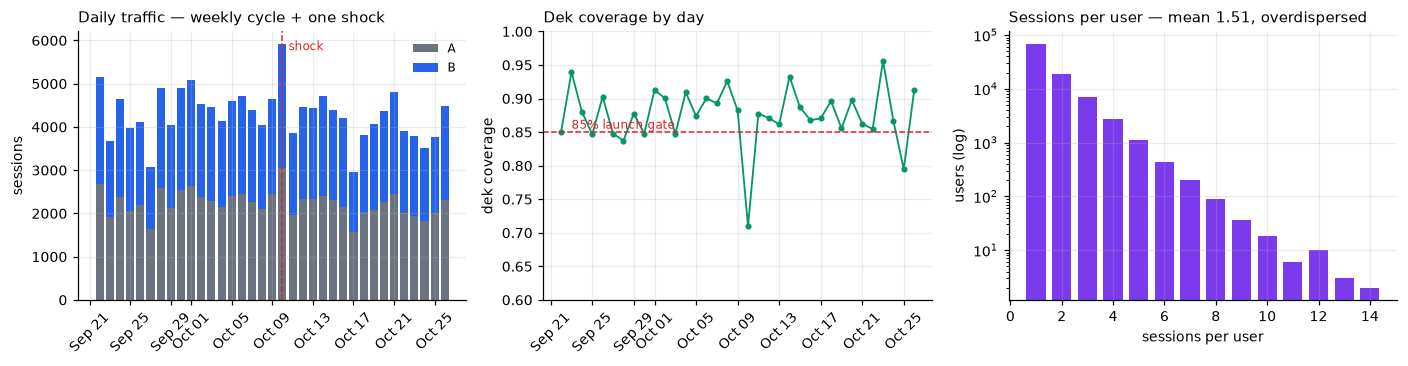

realised coverage 87.422%  (target 88.0%, gate 85%)
realised rates    A 34.0141%  B 38.0633%   (targets 34.1% / 38.2%)


In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
shock_date = pd.Timestamp(START) + pd.Timedelta(days=NEWS_SPIKE_DAY)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# traffic per day, split by arm
piv = (df.assign(d=df.session_date).groupby(["d","variant"]).size()
         .unstack("variant"))
ax[0].bar(piv.index, piv.A, color="#6b7280", width=0.8, label="A")
ax[0].bar(piv.index, piv.B, bottom=piv.A, color="#2563eb", width=0.8, label="B")
ax[0].axvline(shock_date, color="#dc2626", ls="--", lw=1)
ax[0].annotate("shock", (shock_date, ax[0].get_ylim()[1]*0.93), xytext=(4,0),
               textcoords="offset points", fontsize=8, color="#dc2626")
ax[0].set_ylabel("sessions"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("Daily traffic — weekly cycle + one shock", loc="left", fontsize=10)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); ax[0].tick_params(axis="x", rotation=45)

# dek coverage per day
ax[1].plot(pd.to_datetime(days_df.date), days_df.coverage, color="#059669", marker="o", ms=3, lw=1.2)
ax[1].axhline(0.85, color="#dc2626", ls="--", lw=1)
ax[1].annotate("85% launch gate", (pd.to_datetime(days_df.date.iloc[1]), 0.855),
               fontsize=8, color="#dc2626")
ax[1].set_ylim(0.6, 1.0); ax[1].set_ylabel("dek coverage")
ax[1].set_title("Dek coverage by day", loc="left", fontsize=10)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); ax[1].tick_params(axis="x", rotation=45)

# sessions per user
spu = df.groupby("user_id").size().value_counts().sort_index()
ax[2].bar(spu.index, spu.values, color="#7c3aed", width=0.75)
ax[2].set_yscale("log")
ax[2].set_xlabel("sessions per user"); ax[2].set_ylabel("users (log)")
ax[2].set_title(f"Sessions per user — mean {df.groupby('user_id').size().mean():.2f}, overdispersed",
                loc="left", fontsize=10)

plt.tight_layout(); plt.show()

print(f"realised coverage {df.deks_available.sum()/df.inscope_impressions.sum():.3%}  (target "
      f"{DEK_COVERAGE_MEAN:.1%}, gate 85%)")
print(f"realised rates    A {df[df.variant=='A'].clicked.mean():.4%}  "
      f"B {df[df.variant=='B'].clicked.mean():.4%}   (targets {TARGET_A:.1%} / {TARGET_B:.1%})")

---
## Caveats

**The effect size is deliberately generous.** The brief asked for a 10–30% uplift, so the dataset
carries about +12% relative. Step 1 set the ship threshold at +5% and powered for +2%. A real dek
would not plausibly move session CTR by twelve percent.

The consequence shows up throughout this notebook: the clustering correction, the ITT dilution and
the underpowered subscriber segment are all clearly **visible**, but none of them changes the
answer. At a realistic +3% effect each one would be decisive. Set `TARGET_B = 0.351` and re-run to
get that version — it is a much harder test of whether the Step 1 analysis plan is any good.

**Everything here is synthetic.** The generating process is a logistic model we wrote ourselves, so
any "finding" is a property of our own assumptions. The notebook is a rehearsal of the analysis, not
evidence about headlines.